# Barcelona Noise Prediction: OSM Building Heights
This notebook downloads the building footprints from OpenStreetMap (OSM), processes their heights (falling back to number of levels * 3m where precise height is missing), and evaluates the average and max building height within 50m and 100m buffers around the streets.

In [ ]:
import geopandas as gpd
import pandas as pd
import osmnx as ox
import matplotlib.pyplot as plt
import os
import numpy as np

# Try to set osmnx to use overpass efficiently
ox.settings.timeout = 1000

print("Loading street data...")
noise_streets = gpd.read_file("../../layers/BCN_noise_streets.gpkg")
noise_streets['fid'] = noise_streets.index # Assign explicitly a numeric FID
print("Streets CRS:", noise_streets.crs)
print("Number of street segments:", len(noise_streets))

Loading street data...
Streets CRS: EPSG:25831
Number of street segments: 15115


## Download Building Data from OSM
We use `osmnx` to fetch building polygons for Barcelona. Due to the high number of buildings, this can take a few minutes.

In [ ]:
place_name = "Barcelona, Spain"
tags = {'building': True}

print("Downloading buildings from OSM...")
# Note: depending on the osmnx version, this function could be ox.geometries_from_place or ox.features_from_place
try:
    buildings = ox.features_from_place(place_name, tags)
except AttributeError:
    buildings = ox.geometries_from_place(place_name, tags)

print(f"Downloaded {len(buildings)} buildings.")
# Ensure consistent geometry type and CRS
buildings = buildings[buildings.geometry.type.isin(['Polygon', 'MultiPolygon'])]
buildings = buildings.to_crs(noise_streets.crs)
display(buildings.head(3))

Downloaded 68883 buildings.


geometry  \
element  id                                                          
relation 118402  POLYGON ((432186.92 4582237.79, 432192.928 458...   
         155422  POLYGON ((429314.531 4579712.137, 429325.693 4...   
         166399  POLYGON ((430546.795 4580865.293, 430539.951 4...   

                addr:housename addr:housenumber addr:postcode  \
element  id                                                     
relation 118402            NaN              NaN           NaN   
         155422            NaN              NaN           NaN   
         166399            NaN               99         08001   

                     addr:street    building                           name  \
element  id                                                                   
relation 118402              NaN      office         Parlament de Catalunya   
         155422              NaN  grandstand                            NaN   
         166399  Carrer Sant Pau      church  Església de Sant Pau del Camp   

                 wikidata addr:city           amenity  ... official_name:ca  \
element  id                                            ...                    
relation 118402   Q135630       NaN               NaN  ...              NaN   
         155422       NaN       NaN               NaN  ...              NaN   
         166399  Q2101038       NaN  place_of_worship  ...              NaN   

                official_name:es official_name:hu wheelchair:description:de  \
element  id                                                                   
relation 118402              NaN              NaN                       NaN   
         155422              NaN              NaN                       NaN   
         166399              NaN              NaN                       NaN   

                amenity:-2026 name:-2026 name:ca:-2026 building:underground  \
element  id                                                                   
relation 118402           NaN        NaN           NaN                  NaN   
         155422           NaN        NaN           NaN                  NaN   
         166399           NaN        NaN           NaN                  NaN   

                loc_name:es parking:levels  
element  id                                 
relation 118402         NaN            NaN  
         155422         NaN            NaN  
         166399         NaN            NaN  

[3 rows x 553 columns]

## Process Building Heights
OSM doesn't always have exact height in meters ('height' tag).
We'll try to extract 'height' first. If that fails, we fallback to 'building:levels' multiplying each level by 3 meters.
If neither is present, we impute the height using the median building height of the city.

Valid exact heights found: 264
Calculated from levels: 44122
All buildings have an assigned height. Median is: 12.0m


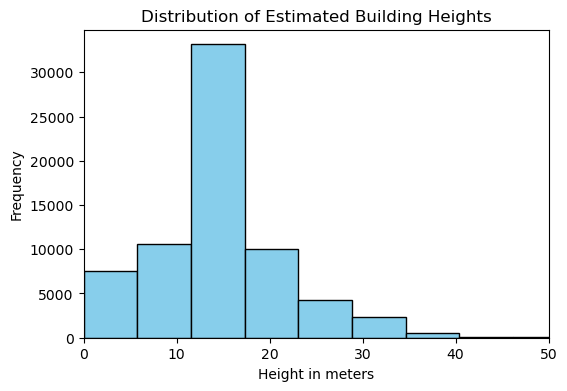

In [ ]:
def clean_height_col(series):
    # Remove non-numeric characters (like 'm', spaces) and convert to float
    if series.dtype == 'O':
        return pd.to_numeric(series.str.replace(r'[^\d.]', '', regex=True), errors='coerce')
    return pd.to_numeric(series, errors='coerce')

# Initialize a series for estimated height
estimated_heights = pd.Series(index=buildings.index, dtype=float)

# 1. Extract exact height if available
if 'height' in buildings.columns:
    estimated_heights = clean_height_col(buildings['height'])
    print(f"Valid exact heights found: {estimated_heights.notna().sum()}")

# 2. Extract levels and multiply by 3
if 'building:levels' in buildings.columns:
    levels = clean_height_col(buildings['building:levels'])
    height_from_levels = levels * 3.0
    # Fill missing exact heights with height from levels
    estimated_heights = estimated_heights.fillna(height_from_levels)
    print(f"Calculated from levels: {height_from_levels.notna().sum()}")

# 3. Give remaining buildings the median height (or a fallback like 6m / 2 stories for a city)
median_height = estimated_heights.median()
if np.isnan(median_height):
    median_height = 9.0  # Fallback to 3 stories if dataset is too sparse
    
estimated_heights = estimated_heights.fillna(median_height)
buildings['estimated_height'] = estimated_heights

print(f"All buildings have an assigned height. Median is: {median_height:.1f}m")

fig, ax = plt.subplots(figsize=(6, 4))
buildings['estimated_height'].plot(kind='hist', bins=50, ax=ax, color='skyblue', edgecolor='black')
ax.set_title('Distribution of Estimated Building Heights')
ax.set_xlabel('Height in meters')
ax.set_xlim(0, 50)  # Focus on the majority
plt.show()

## Buffer Analysis
We calculate the mean and max building height within 50m and 100m for each street. Because we evaluate intersecting buildings, we'll perform a Spatial Join (sjoin).

In [ ]:
def calculate_building_heights_in_buffer(streets_gdf, buildings_gdf, buffer_size):
    print(f"Evaluating {buffer_size}m buffers...")
    # Buffer the streets
    buffered_streets = streets_gdf.copy()
    buffered_streets['geometry'] = buffered_streets.geometry.buffer(buffer_size)
    
    # Keep only target columns for spatial join to reduce memory usage
    bldgs = buildings_gdf[['estimated_height', 'geometry']].copy()
    
    # Spatial join: Which buildings intersect which street buffer?
    joined = gpd.sjoin(buffered_streets[['fid', 'TRAM', 'geometry']], bldgs, how='left', predicate='intersects')
    
    # If a street buffer hits nothing, it will have NaN in estimated_height. We can treat that as 0 (no buildings).
    joined['estimated_height'] = joined['estimated_height'].fillna(0)
    
    # Group by street and calculate aggregate stats
    agg_funcs = {
        'estimated_height': ['mean', 'max']
    }
    grouped = joined.groupby(['fid', 'TRAM']).agg(agg_funcs)
    
    # Flatten MultiIndex columns
    grouped.columns = [f"bldg_h_{col[1]}_{buffer_size}m" for col in grouped.columns]
    
    return grouped.reset_index()

features_50m = calculate_building_heights_in_buffer(noise_streets, buildings, 50)
features_100m = calculate_building_heights_in_buffer(noise_streets, buildings, 100)

display(features_50m.head())

Evaluating 50m buffers...
Evaluating 100m buffers...


,TRAM,bldg_h_mean_50m,bldg_h_max_50m
0,LRD0001,9.00,12.0
1,LRD0002,15.00,15.0
2,LRD0003,5.25,12.0
3,LRD0004,5.25,12.0
4,LRD0005,0.00,0.0


## Merge and Export

In [ ]:
dataset = pd.DataFrame({
    'fid': noise_streets['fid'],
    'street_id': noise_streets['TRAM']
})

dataset = dataset.merge(features_50m, left_on=['fid', 'street_id'], right_on=['fid', 'TRAM'], how='left').drop(columns=['TRAM'], errors='ignore')
dataset = dataset.merge(features_100m, left_on=['fid', 'street_id'], right_on=['fid', 'TRAM'], how='left').drop(columns=['TRAM'], errors='ignore')

dataset = dataset.fillna(0)
display(dataset.head())

output_dir = "../../data/processed"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "osm_building_heights.csv"), index=False)
print("Exported osm_building_heights.csv")

,street_id,bldg_h_mean_50m,bldg_h_max_50m,bldg_h_mean_100m,bldg_h_max_100m
0,T04719W,9.940667,12.09,10.376667,15.0
1,T19941Z,17.076923,24.00,18.571429,39.0
2,T18111R,25.333333,30.00,22.375000,45.0
3,T03222Y,11.754098,30.00,12.454545,36.0
4,T17625I,30.000000,30.00,29.400000,54.0


Exported osm_building_heights.csv


### Visualizing the Building Heights along logic
Let's see our streets colored by the average building height in their 50m buffers.

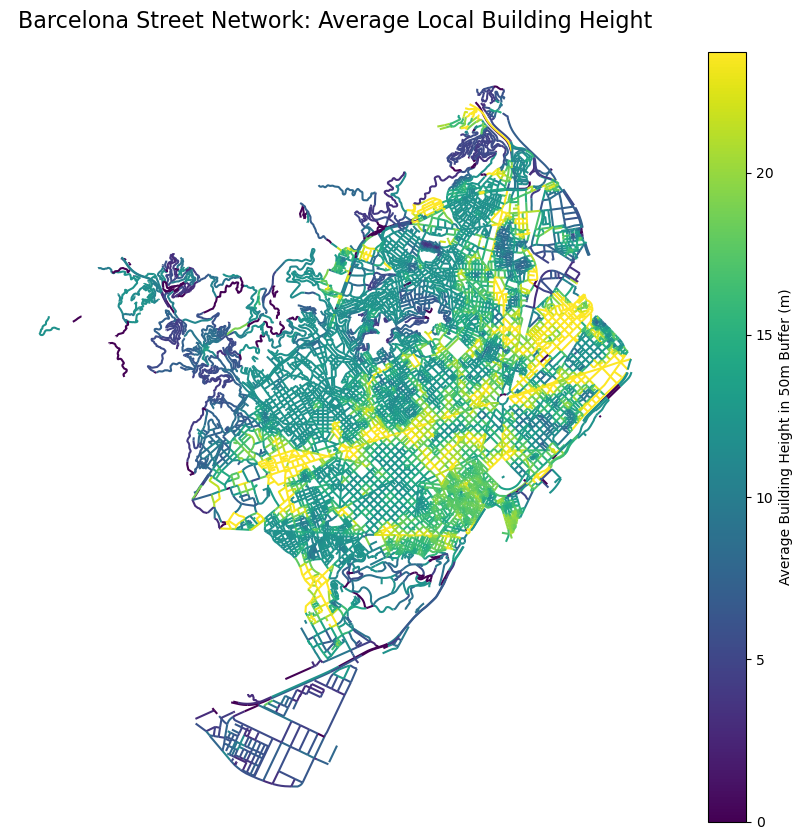

In [ ]:
# Temporarily merge the result back to the street geometries for plotting
viz_gdf = noise_streets.merge(dataset[['street_id', 'bldg_h_mean_50m']], left_on='TRAM', right_on='street_id')

fig, ax = plt.subplots(figsize=(12, 10))

# Cap at 95th percentile so super tall buildings don't wash out the color map gradient
vmax_height = viz_gdf['bldg_h_mean_50m'].quantile(0.95)

viz_gdf.plot(
    column='bldg_h_mean_50m',
    ax=ax,
    cmap='viridis',
    linewidth=1.5,
    legend=True,
    legend_kwds={'label': "Average Building Height in 50m Buffer (m)"},
    vmax=vmax_height
)

ax.set_title("Barcelona Street Network: Average Local Building Height", fontsize=16)
ax.set_axis_off()
plt.show()